## 📌 Project Objective

Build a linear regression model to predict house prices affected by multiple features and this project would include,
- Data overview and analysis using EDA
- EDA charts and key insights
- Linear regression model to find the best fit regression line
- Model evaluation
- Overview of the project through key business and learning insights

### Data overveiw and analysis

In [79]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

#### Load the dataset

In [80]:
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\data\House Price India.csv")

In [81]:
df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


In [82]:
df.describe()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,1.461900e+04,14619.000000,14619.000000,14619.000000,14619.000000,1.461900e+04,14619.000000,14619.000000,14619.000000,14619.000000,...,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,1.461900e+04
mean,6.762821e+09,42604.546412,3.379233,2.129557,2098.156851,1.509369e+04,1.502326,0.007661,0.232848,3.430399,...,1970.929817,90.930228,122033.064300,52.792843,-114.403996,1996.641836,12754.003078,2.012244,64.951433,5.388063e+05
std,6.237162e+03,67.343747,0.938655,0.769955,928.218740,3.792089e+04,0.540241,0.087196,0.765651,0.664047,...,29.491743,416.230218,19.081451,0.137525,0.141325,691.078387,26059.234785,0.817312,8.936129,3.672294e+05
min,6.762810e+09,42491.000000,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,1900.000000,0.000000,122003.000000,52.385900,-114.709000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,6.762815e+09,42546.000000,3.000000,1.750000,1440.000000,5.010500e+03,1.000000,0.000000,0.000000,3.000000,...,1951.000000,0.000000,122017.000000,52.707600,-114.519000,1490.000000,5097.500000,1.000000,57.000000,3.200000e+05
50%,6.762821e+09,42600.000000,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,...,1975.000000,0.000000,122032.000000,52.806400,-114.421000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,6.762826e+09,42662.000000,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,0.000000,0.000000,4.000000,...,1997.000000,0.000000,122048.000000,52.908900,-114.315000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,6.762832e+09,42734.000000,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,...,2015.000000,2015.000000,122072.000000,53.007600,-113.505000,6110.000000,560617.000000,3.000000,80.000000,7.700000e+06


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Ar

#### Remove unnecessary columns from the dataset

In [90]:
df = df.drop(['id','Date','Postal Code','Built Year','Renovation Year','Lattitude','Longitude','living_area_renov','lot_area_renov'], axis=1)

#### Distribution of house prices

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

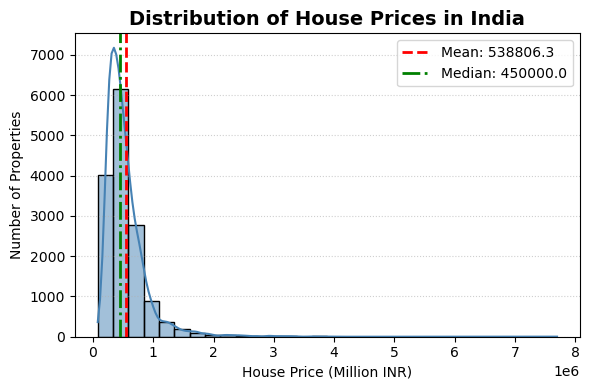

In [92]:
plt.figure(figsize=(6,4))

sns.histplot(
    df["Price"],
    bins=30,
    kde=True,
    color="steelblue",
    edgecolor="black"
)

# Central tendency
mean_price = df["Price"].mean()
median_price = df["Price"].median()

plt.axvline(mean_price, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_price:.1f}")
plt.axvline(median_price, color="green", linestyle="-.", linewidth=2, label=f"Median: {median_price:.1f}")

# Labels & title
plt.title("Distribution of House Prices in India", fontsize=14, fontweight="bold")
plt.xlabel("House Price (Million INR)")
plt.ylabel("Number of Properties")

plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### House area vs price - Scatter plot

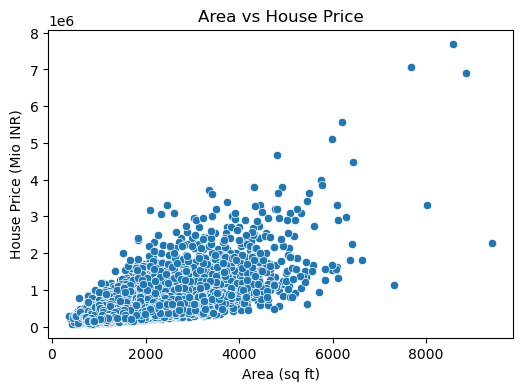

In [93]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Area of the house(excluding basement)"], y=df["Price"])
plt.title("Area vs House Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("House Price (Mio INR)")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\area_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Correlation heatmap

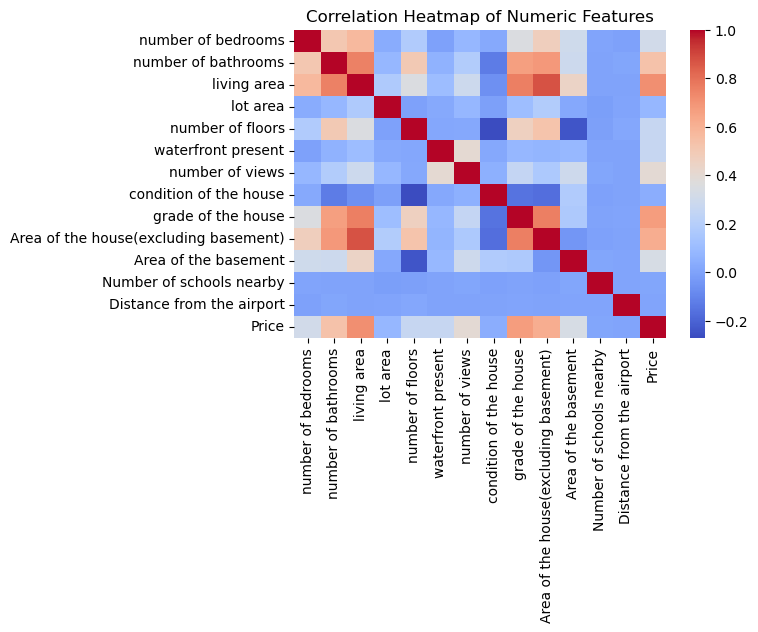

In [95]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), 
            cmap="coolwarm", 
            fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Exploratory Data Analysis – Key Observations

- **Living area is the strongest price driver** (highest correlation with price).
- House grade/quality rating strongly affects valuation → **premium finishing matters**.
- Bathrooms and bedrooms significantly impact price (**buyers value usability, not just size**).
- Basement and built-up area both influence price → **usable indoor space is more important than plot size**.
- Lot area has very low impact → buyers care more about constructed space than land size in urban markets.
- Distance from airport and schools nearby show almost no correlation → these are not primary pricing factors in this dataset.
- Views and waterfront presence moderately increase price → lifestyle features add premium but are secondary.

#### Feature selection

In [96]:
X = df.drop("Price",axis = 1)
y = df["Price"]

#### Split the data

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [98]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

#### Model evaluation

In [70]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE: ", mean_absolute_error(y_test, y_pred))
print("RMSE: ", mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))

MAE:  103255.14120511578
RMSE:  38568291246.56842
R2:  0.7393965202445095


#### Actual vs predicted

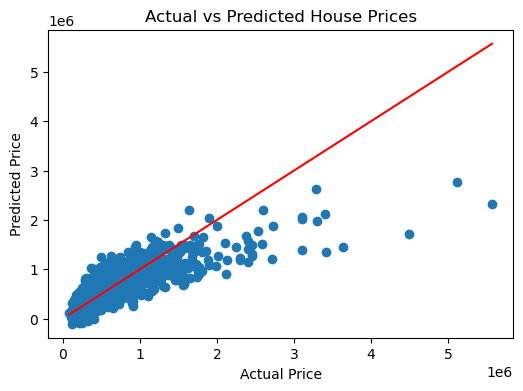

In [99]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\actual_vs_predicted_prices.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Residual calculation

In [100]:
residuals = y_test - y_pred

#### Residual distribution

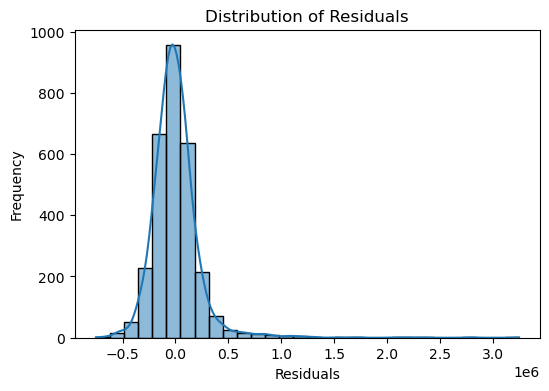

In [101]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 📌 Key insights and learning summary

### Linear Regression performance

- MAE:  103255
- RMSE:  38568291246
- R2:  0.74

### 🧠 Key Analytical Insights

#### Property characteristics (Primary drivers)

- Living area is the strongest predictor of house price
- House grade/quality significantly increases valuation
- Number of bathrooms and bedrooms positively influence price
- Usable built-up area (excluding basement) affects price more than total land area
- Basement area adds additional value but less than main living space
- Premium & lifestyle features
- Waterfront properties and scenic views increase property value
- Higher number of floors moderately increases price
- Property condition contributes to price but less than construction grade

#### Weak influencing factors

- Distance from airport has negligible impact on pricing
- Number of nearby schools shows very low correlation with price
→ Buyers prioritize house features over nearby amenities in this dataset

#### Market behavior insight

- Price distribution is right-skewed → majority homes are affordable/mid-range
- Few luxury homes form a high-price segment (outliers)
- Same area houses can have different prices due to quality and premium features

### 🏁 Conclusion

Multiple Linear Regression successfully estimates housing prices using structural and quality-based features. The model is interpretable and useful for approximate valuation, but prediction accuracy reduces for luxury segment properties due to high variability and hidden market factors (location prestige, builder reputation, interior quality).
    
### Key business takeaway:
                                                                                                        
A property’s market value is primarily driven by usable living space and construction quality rather than land size or external amenities.
Using predictive pricing models allows real estate platforms, banks, and buyers to estimate fair property value, avoid overpricing/underpricing, and make data-driven investment or loan decisions.

#### Save the model

In [103]:
import joblib

joblib.dump(lr_model, "house_price_model.pkl")

['house_price_model.pkl']

In [104]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']